# MATH 189 Final Project  
## Comparative Analysis of Conventional and Renewable Energy in the United States: Generation Trends, Capacity Factors, and Cost

**Team Members:**  Anand Baidya, Dhruv Sehgal, Donghyun Koo, Daniel Huang, Kayla Li 

**Instructor:**  Siddharth Vishwanath

**Date:** March 14, 2026

## 1. Introduction

Energy production plays a critical role in modern economies, but the environmental and economic implications of different energy sources remain a major concern. In recent years, renewable energy technologies have expanded rapidly as alternatives to fossil fuels.

This project investigates differences between conventional fossil fuel energy sources and renewable energy sources using publicly available energy datasets.

Specifically, we aim to analyze:

- Efficiency and capacity factors of energy generation sources
- Net generation trends across energy types
- Cost trends associated with renewable energy technologies

To study this question, we focus on three measurable aspects of the energy transition: electricity generation, capacity factor, and levelized cost of electricity (LCOE). Generation reflects how much electricity each source actually contributes to the grid, capacity factor captures how consistently a source produces power relative to its maximum possible output, and LCOE provides a standardized cost measure for renewable technologies. Together, these variables allow us to compare conventional and renewable sources from both operational and economic perspectives.

### Background and Prior Work
This project builds on public energy analyses already published by major energy agencies. The U.S. Energy Information Administration (EIA) routinely reports annual U.S. electricity generation by source and has documented the long-term rise of natural gas, wind, and solar alongside the decline of coal in the national electricity mix. The International Renewable Energy Agency (IRENA) has also shown that the levelized cost of electricity for renewables—especially solar PV and onshore wind—has fallen substantially over the last decade. These prior reports motivated our project by suggesting that the energy transition is visible both in cost data and in real generation patterns. At the same time, cost metrics such as LCOE have known limitations, because they do not fully capture dispatchability, storage needs, or grid integration costs.

### Relation to Project Proposal
This final report remains closely aligned with the core objectives established in the initial project proposal. The primary goal of quantitatively evaluating the transition from conventional energy sources to renewables—specifically by analyzing generation trends, operational efficiency, and cost—served as the central framework for all analyses performed.

While the original proposal suggested a global scope involving international datasets like the World Bank and IEA, the final project was refined to focus specifically on the United States. This decision allowed for a more consistent and granular comparison by prioritizing high-quality data from the EIA and IRENA. Narrowing the geographic scope ensured that variables such as the Levelized Cost of Energy (LCOE) and annual capacity factors were evaluated within a single regulatory and economic context, leading to more reliable statistical conclusions.

The methodology also evolved during the exploratory phase to better suit the specific distributions of the data. While the planned non-parametric tests were utilized to compare efficiency, the addition of One-Way ANOVA and Pearson correlation analysis provided a more robust understanding of the relationship between falling implementation costs and rising net generation. Ultimately, the project successfully fulfilled the proposed intent to highlight the economic and operational trade-offs inherent in the energy transition.

## 2. Data Sources

We used publicly available datasets from the U.S. Energy Information Administration (EIA) and the International Renewable Energy Agency (IRENA).

### 1. U.S. Energy Information Administration (EIA)

The EIA data provided annual U.S. net electricity generation by source and annual capacity factor data for coal, natural gas, wind, and solar. The generation data covered the long-term U.S. electricity mix, while the capacity factor data provided a measure of operational consistency for each technology.

Datasets used include:
- Net electricity generation by source
- Capacity factor data for fossil and renewable sources

### 2. International Renewable Energy Agency (IRENA)

The IRENA dataset provided annual levelized cost of electricity (LCOE) values for renewable technologies, including solar photovoltaic and onshore wind, with both global values and U.S.-specific values when available. We used the U.S. values for the main regression analysis and used the broader global trends for descriptive comparison.

These sources were selected because they are authoritative, publicly available, and complementary: EIA captures actual U.S. electricity production, while IRENA captures the changing economics of renewable deployment.

Because the datasets did not cover identical year ranges, some analyses use a longer historical window while others use a reduced overlapping sample.

## 3. Data Description

The combined dataset contains information on energy generation across multiple years and technologies.

Key variables include:

- **Energy Source** – type of generation technology (coal, natural gas, solar, wind, etc.)
- **Year** – year of recorded data
- **Capacity Factor** – ratio of actual output relative to maximum possible output
- **Net Generation** – total electricity produced
- **Cost Metrics** – generation cost per technology (from IRENA)

Before analysis, the datasets required several preprocessing steps:
- cleaning missing values
- standardizing year formats
- merging generation and efficiency datasets
- filtering relevant energy technologies

## 4. Data Cleaning and Preprocessing

The raw files required several preprocessing steps before analysis. Year fields were standardized across sources, irrelevant columns were removed, and energy source labels were harmonized so that the EIA generation data, EIA capacity factor data, and IRENA cost data could be compared consistently. Missing observations were dropped only when necessary for a given analysis. Because the datasets did not align perfectly in time, we created both source-specific cleaned tables and a reduced merged dataset containing only the overlapping years needed for direct comparison.

Missing U.S.-specific LCOE values in the IRENA data were excluded only for analyses that required U.S. cost estimates. This preserved the largest possible sample while avoiding imputation assumptions that could distort the cost trends.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

### 4.1 Cleaning the IRENA Cost Data (LCOE)

In [2]:
excel_file = 'IRENA-Datafile-RenPwrGenCosts-in-2024.xlsx'

# Create a list of years as strings for easier filtering
years = [str(year) for year in range(2010, 2025)]

# 1. Clean Global LCOE Data (from the 'Fig 1.2 ' sheet)
df_global = pd.read_excel(excel_file, sheet_name='Fig 1.2 ', skiprows=4)
df_global.columns = df_global.columns.astype(str) # Ensure years are read as strings
df_global = df_global.rename(columns={'Unnamed: 1': 'Technology'})
df_global = df_global.dropna(subset=['Technology'])
df_global_long = df_global.melt(id_vars=['Technology'], value_vars=years, var_name='Year', value_name='Global_LCOE_USD_per_kWh')

# 2. Clean US Onshore Wind LCOE Data (from the 'Fig 2.15' sheet)
df_wind = pd.read_excel(excel_file, sheet_name='Fig 2.15', skiprows=6)
df_wind.columns = df_wind.columns.astype(str)
df_wind_us = df_wind[df_wind['Country'] == 'United States'].copy()
df_wind_us = df_wind_us[['Country'] + years]
df_wind_us_long = df_wind_us.melt(id_vars=['Country'], var_name='Year', value_name='US_LCOE_USD_per_kWh')
df_wind_us_long['Technology'] = 'Onshore wind'

# 3. Clean US Solar PV LCOE Data (from the 'Fig. 3.10' sheet)
df_solar = pd.read_excel(excel_file, sheet_name='Fig. 3.10', skiprows=2)
df_solar.columns = df_solar.columns.astype(str)
df_solar = df_solar.rename(columns={'Unnamed: 2': 'Country'})
df_solar_us = df_solar[df_solar['Country'] == 'United States'].copy()
df_solar_us = df_solar_us[['Country'] + years]
df_solar_us_long = df_solar_us.melt(id_vars=['Country'], var_name='Year', value_name='US_LCOE_USD_per_kWh')
df_solar_us_long['Technology'] = 'Solar photovoltaic'

# 4. Combine US Data and Merge with Global Data
df_us_combined = pd.concat([df_wind_us_long, df_solar_us_long], ignore_index=True)
df_final = pd.merge(df_global_long, df_us_combined, on=['Year', 'Technology'], how='outer')

# 5. Save the final cleaned dataset
df_final.to_csv('Cleaned_IRENA_LCOE_Data.csv', index=False)

df_cleaned_irena = pd.read_csv('Cleaned_IRENA_LCOE_Data.csv')

### 4.2 Cleaning the EIA Efficiency Data (Fossil vs. Non-Fossil)

In [23]:
url_renewable = "https://www.eia.gov/electricity/annual/html/epa_04_08_b.html"
url_fossil = "https://www.eia.gov/electricity/monthly/epm_table_grapher.php?t=table_6_07_a"

def read_main_table(url: str) -> pd.DataFrame:
    tables = pd.read_html(url)
    for table in tables:
        if isinstance(table.columns, pd.MultiIndex) and table.shape[1] > 5:
            return table.copy()
    raise ValueError(f"Could not find main table at {url}")

def flatten_columns(columns) -> list[str]:
    flat = []
    for col in columns:
        if isinstance(col, tuple):
            parts = [str(x).strip() for x in col if str(x).strip() and not str(x).startswith("Unnamed")]
            flat.append(" | ".join(parts))
        else:
            flat.append(str(col).strip())
    return flat

raw_renew = read_main_table(url_renewable)
raw_fossil = read_main_table(url_fossil)
raw_renew.columns = flatten_columns(raw_renew.columns)
raw_fossil.columns = flatten_columns(raw_fossil.columns)

def keep_annual_year_rows(df: pd.DataFrame) -> pd.DataFrame:
    year_col = next(c for c in df.columns if "Year/Month" in c)
    out = df.rename(columns={year_col: "Year"}).copy()
    out["Year"] = out["Year"].astype(str).str.strip()
    out = out[out["Year"].str.fullmatch(r"\d{4}")].copy()
    out["Year"] = out["Year"].astype(int)
    return out

def to_number(series: pd.Series) -> pd.Series:
    cleaned = series.astype(str).str.replace(",", "", regex=False).str.strip()
    return pd.to_numeric(cleaned, errors="coerce")

def percent_to_decimal(series: pd.Series) -> pd.Series:
    cleaned = series.astype(str).str.replace("%", "", regex=False).str.strip()
    return pd.to_numeric(cleaned, errors="coerce") / 100.0

renew = keep_annual_year_rows(raw_renew)
fossil = keep_annual_year_rows(raw_fossil)

# Wind directly
df_renewable = pd.DataFrame({
    "Year": renew["Year"],
    "Wind_CF": percent_to_decimal(renew["Wind | Capacity Factor"]),
})

# Solar = capacity-weighted PV + Thermal
solar_cap_cols = [
    "Solar | Photovoltaic | Time Adjusted Capacity (MW)",
    "Solar | Thermal | Time Adjusted Capacity (MW)",
]
solar_cf_cols = [
    "Solar | Photovoltaic | Capacity Factor",
    "Solar | Thermal | Capacity Factor",
]
solar_caps = renew[solar_cap_cols].apply(to_number)
solar_cfs = renew[solar_cf_cols].apply(percent_to_decimal)
df_renewable["Solar_CF"] = solar_caps.mul(solar_cfs.values).sum(axis=1) / solar_caps.sum(axis=1)

# Coal directly
df_fossil = pd.DataFrame({
    "Year": fossil["Year"],
    "Coal_CF": percent_to_decimal(fossil["Coal | Capacity Factor"]),
})

# Natural Gas = capacity-weighted average of all NG subtypes
ng_cap_cols = [
    "Natural Gas | Combined Cycle | Time Adjusted Capacity (MW)",
    "Natural Gas | Gas Turbine | Time Adjusted Capacity (MW)",
    "Natural Gas | Steam Turbine | Time Adjusted Capacity (MW)",
    "Natural Gas | Internal Combustion | Time Adjusted Capacity (MW)",
]
ng_cf_cols = [
    "Natural Gas | Combined Cycle | Capacity Factor",
    "Natural Gas | Gas Turbine | Capacity Factor",
    "Natural Gas | Steam Turbine | Capacity Factor",
    "Natural Gas | Internal Combustion | Capacity Factor",
]
ng_caps = fossil[ng_cap_cols].apply(to_number)
ng_cfs = fossil[ng_cf_cols].apply(percent_to_decimal)
df_fossil["Natural_Gas_CF"] = ng_caps.mul(ng_cfs.values).sum(axis=1) / ng_caps.sum(axis=1)

master_capacity_factors = (
    pd.merge(df_fossil, df_renewable, on="Year", how="inner")
    .sort_values("Year")
    .reset_index(drop=True)
)

master_capacity_factors.to_csv("EIA_capacity_factor_master.csv", index=False)

master_capacity_factors


,Year,Coal_CF,Natural_Gas_CF,Wind_CF,Solar_CF
0,2015,0.543,0.343583,0.322,0.249251
1,2016,0.528,0.347525,0.345,0.246798
2,2017,0.531,0.321601,0.346,0.253181
3,2018,0.536,0.358252,0.346,0.250088
4,2019,0.475,0.377887,0.344,0.241378
5,2020,0.405,0.378305,0.353,0.240473
6,2021,0.491,0.365794,0.344,0.242798
7,2022,0.484,0.384295,0.359,0.243708
8,2023,0.424,0.406714,0.332,0.231793
9,2024,0.426,0.417757,0.343,0.232242


### 4.3 Cleaning the EIA Net Generation Data

In [4]:
# 1. Load the dataset (skipping the first 4 rows of EIA metadata)
df_gen_raw = pd.read_csv('Net_generation_for_all_sectors.csv', skiprows=4)

# 2. Define the exact rows we want to keep and what to rename them to
sources = {
    'United States : coal': 'Coal_Generation_TWh',
    'United States : natural gas': 'Natural_Gas_Generation_TWh',
    'United States : wind': 'Wind_Generation_TWh',
    'United States : all utility-scale solar': 'Solar_Generation_TWh'
}

# Filter and rename
df_filtered = df_gen_raw[df_gen_raw['description'].isin(sources.keys())].copy()
# Drop duplicate rows (EIA sometimes includes the same row twice in their CSVs)
df_filtered = df_filtered.drop_duplicates(subset=['description'])
df_filtered['description'] = df_filtered['description'].map(sources)

# Drop the 'units' and 'source key' columns
df_filtered = df_filtered.drop(columns=['units', 'source key'])

# 3. Melt the data (turn year columns into rows)
df_melted = df_filtered.melt(id_vars=['description'], var_name='Year', value_name='Generation_Thousand_MWh')

# 4. Pivot the data so each energy source gets its own column
df_gen_clean = df_melted.pivot(index='Year', columns='description', values='Generation_Thousand_MWh').reset_index()

# 5. Clean up data types and convert Thousand MWh to TWh (divide by 1,000,000)
df_gen_clean['Year'] = pd.to_numeric(df_gen_clean['Year'], errors='coerce')
df_gen_clean = df_gen_clean.dropna(subset=['Year']) # Drop any non-year rows
df_gen_clean['Year'] = df_gen_clean['Year'].astype(int)

for col in sources.values():
    df_gen_clean[col] = pd.to_numeric(df_gen_clean[col], errors='coerce') / 1000000

# Sort by Year and reset index
df_gen_clean = df_gen_clean.sort_values('Year').reset_index(drop=True)
# Get rid of the pivot column name index for a cleaner dataframe
df_gen_clean.columns.name = None

# Save to CSV
df_gen_clean.to_csv('Cleaned_EIA_Generation_Data.csv', index=False)

print("Cleaned Generation Data:")
print(df_gen_clean.head())

Cleaned Generation Data:
   Year  Coal_Generation_TWh  Natural_Gas_Generation_TWh  \
0  2001             1.903956                    0.639129   
1  2002             1.933130                    0.691006   
2  2003             1.973737                    0.649908   
3  2004             1.978301                    0.710100   
4  2005             2.012873                    0.760960   

   Solar_Generation_TWh  Wind_Generation_TWh  
0              0.000543             0.006737  
1              0.000555             0.010354  
2              0.000534             0.011187  
3              0.000575             0.014144  
4              0.000550             0.017811  


### 4.4 Merging
Now we have Cleaned_EIA_Generation_Data.csv (Generation) and EIA_capacity_factor_master.csv (Efficiency). We can merge them together so we have a unified US Energy dataset ready for statistical tests.

In [5]:
df_master_us = pd.merge(df_gen_clean, master_capacity_factors, on='Year', how='inner')

# merge the IRENA Cost Data (LCOE)
df_irena = pd.read_csv('Cleaned_IRENA_LCOE_Data.csv')
# only want the US data for this specific dataset
df_irena_us = df_irena[df_irena['Country'] == 'United States'].pivot(index='Year', columns='Technology', values='US_LCOE_USD_per_kWh').reset_index()
df_irena_us.rename(columns={'Onshore wind': 'Wind_LCOE', 'Solar photovoltaic': 'Solar_LCOE'}, inplace=True)

# Final Merge
df_final_master = pd.merge(df_master_us, df_irena_us[['Year', 'Wind_LCOE', 'Solar_LCOE']], on='Year', how='left')

print(df_final_master.head())
df_final_master.to_csv('Final_US_Energy_Master.csv', index=False)

   Year  Coal_Generation_TWh  Natural_Gas_Generation_TWh  \
0  2015             1.352398                    1.334668   
1  2016             1.239149                    1.379271   
2  2017             1.205835                    1.297703   
3  2018             1.149487                    1.471843   
4  2019             0.964957                    1.588533   

   Solar_Generation_TWh  Wind_Generation_TWh  Coal_CF  Natural_Gas_CF  \
0              0.024893             0.190719    0.543        0.343583   
1              0.036054             0.226993    0.528        0.347525   
2              0.053287             0.254303    0.531        0.321601   
3              0.063825             0.272667    0.536        0.358252   
4              0.071937             0.295882    0.475        0.377887   

   Wind_CF  Solar_CF  Wind_LCOE  Solar_LCOE  
0    0.322  0.249251   0.062426    0.160476  
1    0.345  0.246798   0.057356    0.143374  
2    0.346  0.253181   0.050258    0.105427  
3    0.346  0.25

After cleaning, the project used three main analytic tables:
- (1) a generation dataset covering annual U.S. electricity generation by source,
- (2) a capacity factor dataset covering annual values for coal, natural gas, wind, and solar, and
- (3) a renewable cost dataset containing annual LCOE values for onshore wind and solar PV.

The final merged dataset used for direct comparison across generation, capacity factor, and cost covered 2015–2024 and contained 10 yearly observations. The larger generation dataset used for long-run trend analyses covered roughly 2001–2025. Net generation was measured in terawatt-hours (TWh), capacity factor was recorded as a decimal proportion, and LCOE was measured in U.S. dollars per kilowatt-hour.

## 5. Exploratory Data Analysis

Before performing statistical analysis, we explored the data to identify patterns, trends, and potential anomalies.

Key questions explored include:

- How does generation vary across energy sources?
- Do renewable sources show increasing trends over time?
- How do capacity factors compare between fossil and renewable technologies?

### 5.1 Summary Statistics and Missing Values
#### Summary statistics for the IRENA LCOE data

In [6]:
df_irena = pd.read_csv('Cleaned_IRENA_LCOE_Data.csv')
print("--- IRENA LCOE Summary Statistics ---")
print(df_irena[['Global_LCOE_USD_per_kWh', 'US_LCOE_USD_per_kWh']].describe())

--- IRENA LCOE Summary Statistics ---
       Global_LCOE_USD_per_kWh  US_LCOE_USD_per_kWh
count               104.000000            30.000000
mean                  0.110249             0.100714
std                   0.085461             0.074722
min                   0.033129             0.029544
25%                   0.058736             0.052032
50%                   0.078143             0.068630
75%                   0.119220             0.118180
max                   0.416956             0.295976


The descriptive statistics show that renewable LCOE values vary substantially across time, especially for solar, whose early observations are much higher than later ones. This indicates a strong downward trend rather than a stable distribution over time. The capacity factor dataset contains no missing values and covers a compact 10-year window, making it suitable for direct annual comparison between technologies.

The high spread in solar LCOE should not be interpreted as measurement error; instead, it reflects rapid technological and market change over the study period.

#### Summary statistics for the EIA Capacity Factor data

In [7]:
print("Rows:", len(master_capacity_factors))

print("Year range:", int(master_capacity_factors["Year"].min()), "to", int(master_capacity_factors["Year"].max()))

print("\nMissing values by column:")

print(master_capacity_factors.isna().sum())

master_capacity_factors.describe()

Rows: 10
Year range: 2015 to 2024

Missing values by column:
Year              0
Coal_CF           0
Natural_Gas_CF    0
Wind_CF           0
Solar_CF          0
dtype: int64


,Year,Coal_CF,Natural_Gas_CF,Wind_CF,Solar_CF
count,10.00000,10.000000,10.000000,10.000000,10.000000
mean,2019.50000,0.484300,0.370171,0.343400,0.243171
std,3.02765,0.051277,0.029183,0.010222,0.007134
min,2015.00000,0.405000,0.321601,0.322000,0.231793
25%,2017.25000,0.438250,0.350207,0.343250,0.240699
50%,2019.50000,0.487500,0.371840,0.344500,0.243253
75%,2021.75000,0.530250,0.382797,0.346000,0.248638
max,2024.00000,0.543000,0.417757,0.359000,0.253181


### 5.2 Time Series Trends: Efficiency and Cost over Time

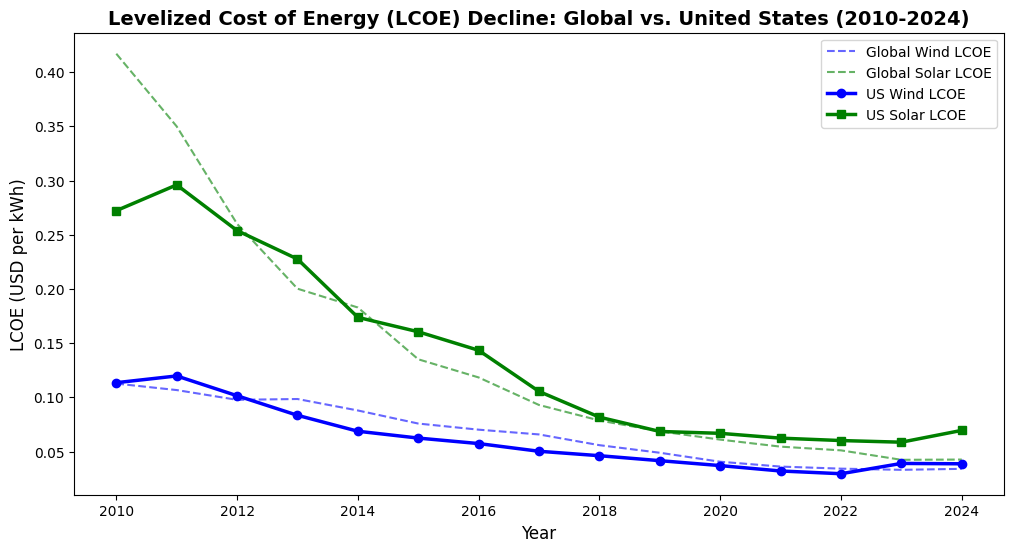

In [8]:
plt.figure(figsize=(12, 6))

# Filter for the technologies we care about
df_wind = df_irena[df_irena['Technology'] == 'Onshore wind']
df_solar = df_irena[df_irena['Technology'] == 'Solar photovoltaic']

# Plot Global trends (dashed lines)
plt.plot(df_wind['Year'], df_wind['Global_LCOE_USD_per_kWh'], label='Global Wind LCOE', color='blue', linestyle='--', alpha=0.6)
plt.plot(df_solar['Year'], df_solar['Global_LCOE_USD_per_kWh'], label='Global Solar LCOE', color='green', linestyle='--', alpha=0.6)

# Plot US trends (solid lines with markers)
# We drop NAs just for the US line plotting so the line connects cleanly
df_wind_us = df_wind.dropna(subset=['US_LCOE_USD_per_kWh'])
df_solar_us = df_solar.dropna(subset=['US_LCOE_USD_per_kWh'])

plt.plot(df_wind_us['Year'], df_wind_us['US_LCOE_USD_per_kWh'], label='US Wind LCOE', color='blue', marker='o', linewidth=2.5)
plt.plot(df_solar_us['Year'], df_solar_us['US_LCOE_USD_per_kWh'], label='US Solar LCOE', color='green', marker='s', linewidth=2.5)

plt.title('Levelized Cost of Energy (LCOE) Decline: Global vs. United States (2010-2024)', fontsize=14, fontweight='bold')
plt.ylabel('LCOE (USD per kWh)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend()
plt.savefig('IRENA_LCOE_Trends.png', bbox_inches='tight')
plt.show()

#### Figure 1. LCOE decline for wind and solar

Figure 1 shows a substantial decline in both wind and solar LCOE over time, with the drop being much steeper for solar PV. This pattern suggests that renewables, especially solar, became increasingly cost-competitive during the study period. Because the decline is visibly nonlinear and spans multiple years, later inferential analyses must be interpreted in the context of strong time trends.

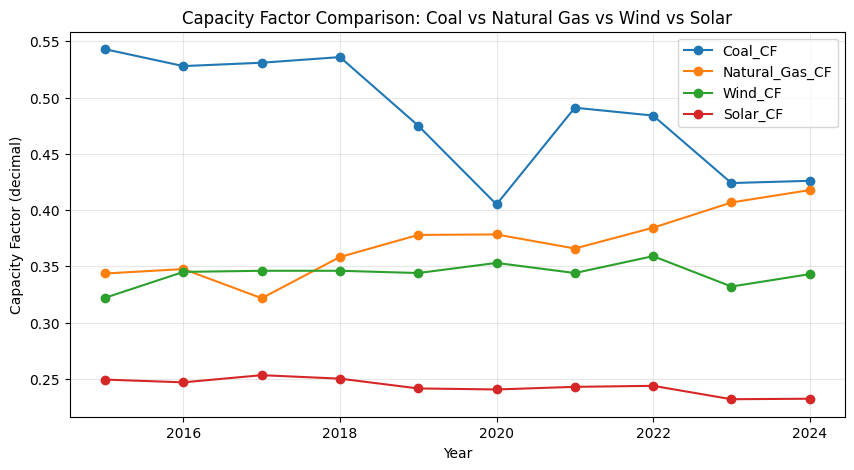

In [9]:
plot_df = master_capacity_factors.set_index("Year")[["Coal_CF", "Natural_Gas_CF", "Wind_CF", "Solar_CF"]]
ax = plot_df.plot(figsize=(10, 5), marker="o")
ax.set_title("Capacity Factor Comparison: Coal vs Natural Gas vs Wind vs Solar")
ax.set_ylabel("Capacity Factor (decimal)")
ax.grid(alpha=0.3)
plt.savefig('EIA_Capacity_Factors_Trend.png', bbox_inches='tight') # Saves the image
plt.show()

#### Figure 2. Capacity factor comparison across energy sources

Figure 2 shows that coal and natural gas generally have higher capacity factors than wind and solar, while wind consistently exceeds solar. This pattern motivated our later formal comparison between wind and solar capacity factors.

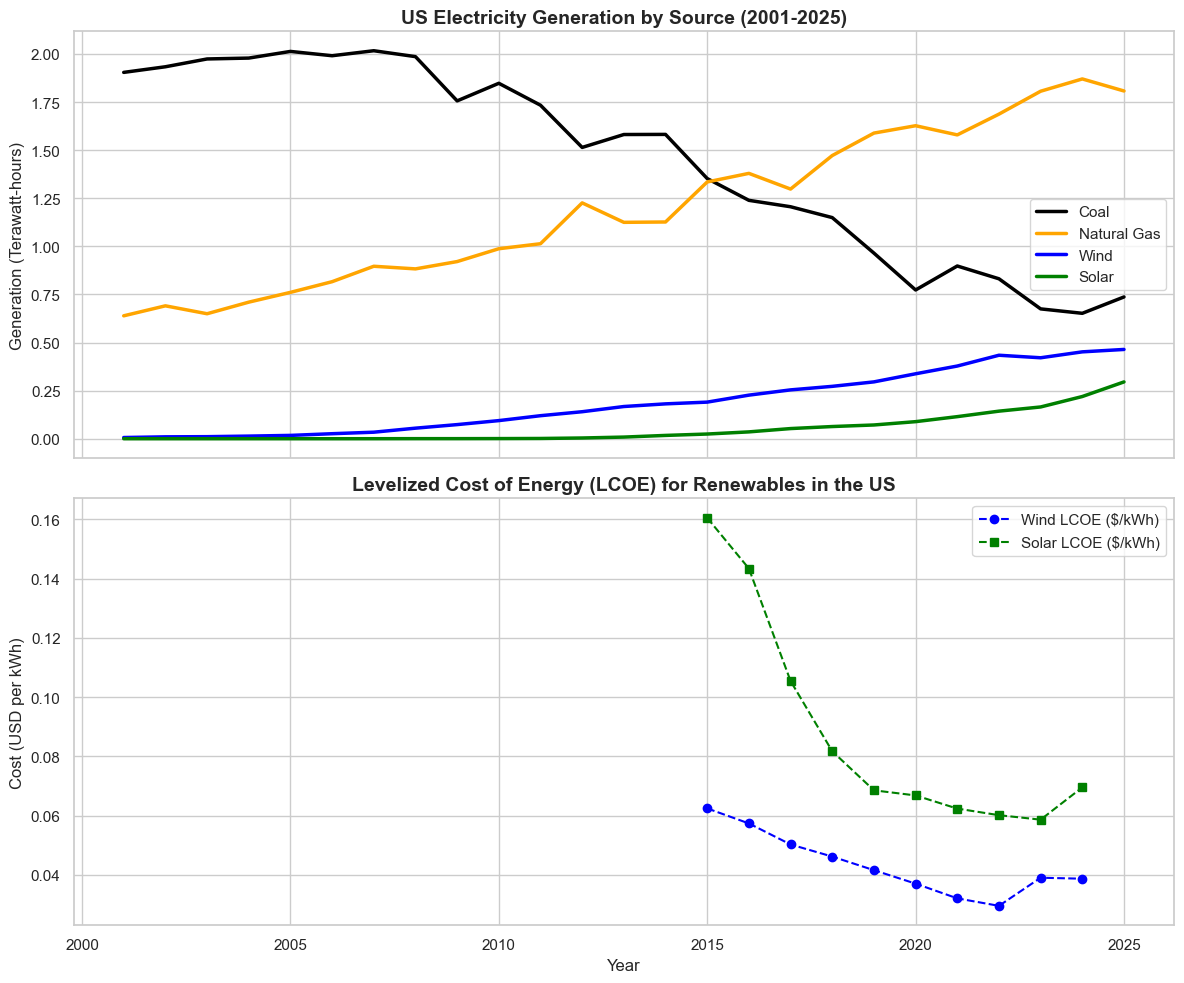

In [10]:
sns.set_theme(style="whitegrid")

# Create a figure with 2 subplots (1 for Generation, 1 for Capacity Factor)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# --- Plot 1: Electricity Generation ---
ax1.plot(df_gen_clean['Year'], df_gen_clean['Coal_Generation_TWh'], label='Coal', color='black', linewidth=2.5)
ax1.plot(df_gen_clean['Year'], df_gen_clean['Natural_Gas_Generation_TWh'], label='Natural Gas', color='orange', linewidth=2.5)
ax1.plot(df_gen_clean['Year'], df_gen_clean['Wind_Generation_TWh'], label='Wind', color='blue', linewidth=2.5)
ax1.plot(df_gen_clean['Year'], df_gen_clean['Solar_Generation_TWh'], label='Solar', color='green', linewidth=2.5)

ax1.set_title('US Electricity Generation by Source (2001-2025)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Generation (Terawatt-hours)', fontsize=12)
ax1.legend()

# --- Plot 2: Cost (LCOE) ---
# We use the merged dataset for this to show how costs falling relates to generation
ax2.plot(df_final_master['Year'], df_final_master['Wind_LCOE'], label='Wind LCOE ($/kWh)', color='blue', linestyle='--', marker='o')
ax2.plot(df_final_master['Year'], df_final_master['Solar_LCOE'], label='Solar LCOE ($/kWh)', color='green', linestyle='--', marker='s')

ax2.set_title('Levelized Cost of Energy (LCOE) for Renewables in the US', fontsize=14, fontweight='bold')
ax2.set_ylabel('Cost (USD per kWh)', fontsize=12)
ax2.set_xlabel('Year', fontsize=12)
ax2.legend()

plt.tight_layout()
plt.savefig('Generation_and_Cost_Trends.png', bbox_inches='tight')
plt.show()

#### Figure 3. U.S. electricity generation and renewable cost trends

Figure 3 suggests a structural shift in the U.S. electricity mix: coal declines over time, natural gas rises, and wind and solar expand from much lower starting points. This figure supports the broader motivation of the project, although visual co-movement alone does not establish causal substitution among sources.

### 5.3 Distribution and Outliers (Boxplots)


/var/folders/wm/v9fd1sw51cl5wm5ysmw94cxw0000gn/T/ipykernel_72982/3773478581.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Technology', y='US_LCOE_USD_per_kWh', data=df_boxplot, palette=['blue', 'green'])


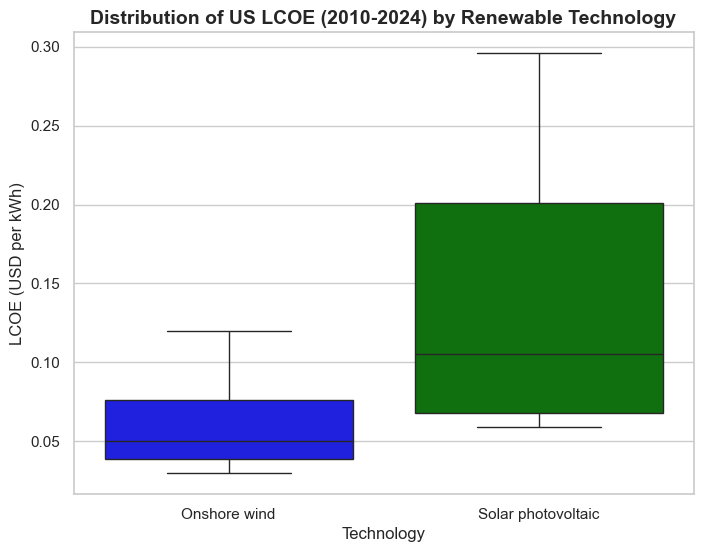

In [11]:
plt.figure(figsize=(8, 6))
df_boxplot = df_irena.dropna(subset=['US_LCOE_USD_per_kWh'])

sns.boxplot(x='Technology', y='US_LCOE_USD_per_kWh', data=df_boxplot, palette=['blue', 'green'])
plt.title('Distribution of US LCOE (2010-2024) by Renewable Technology', fontsize=14, fontweight='bold')
plt.ylabel('LCOE (USD per kWh)', fontsize=12)
plt.xlabel('Technology', fontsize=12)
plt.savefig('IRENA_LCOE_Boxplots.png', bbox_inches='tight')
plt.show()

#### Figure 4. Distribution of U.S. renewable LCOE

Figure 4 shows that the renewable cost distributions, especially for solar, are highly skewed over time because early-decade values are much larger than recent values. This observation is important for understanding the cost data descriptively, but it does not directly determine the test used for capacity factor comparisons. For the wind-versus-solar capacity factor analysis, we chose a nonparametric method because the sample is small (10 yearly observations per group) and we did not want to rely heavily on normality assumptions.

### 5.4 Summary of Final Analytical Dataset
The data cleaning and merging process has resulted in a single, unified dataframe called `df_final_master`. Due to the availability of the EIA efficiency data, our final analytical dataset covers 10 consecutive years (2015–2024).

**Data Dictionary for `df_final_master` (11 Columns):**
1. `Year`: The year of observation.
2. `Coal_Generation_TWh`: Total electricity generated by coal in Terawatt-hours.
3. `Natural_Gas_Generation_TWh`: Total electricity generated by natural gas in Terawatt-hours.
4. `Solar_Generation_TWh`: Total electricity generated by utility-scale solar in Terawatt-hours.
5. `Wind_Generation_TWh`: Total electricity generated by onshore wind in Terawatt-hours.
6. `Coal_CF`: Capacity factor (efficiency/uptime) of coal plants, expressed as a decimal.
7. `Natural_Gas_CF`: Capacity factor (efficiency/uptime) of natural gas plants, expressed as a decimal.
8. `Wind_CF`: Capacity factor (efficiency/uptime) of wind power, expressed as a decimal.
9. `Solar_CF`: Capacity factor (efficiency/uptime) of solar power, expressed as a decimal.
10. `Wind_LCOE`: Levelized Cost of Energy for onshore wind, measured in $USD/kWh.
11. `Solar_LCOE`: Levelized Cost of Energy for solar PV, measured in $USD/kWh.

| Dataset                 |     Years |                      N | Main variables                                  |
| ----------------------- | --------: | ---------------------: | ----------------------------------------------- |
| Generation dataset      | 2001–2025 |    annual observations | coal, natural gas, wind, solar generation       |
| Capacity factor dataset | 2015–2024 | 10 annual observations | coal, natural gas, wind, solar capacity factor  |
| Final merged dataset    | 2015–2024 | 10 annual observations | generation + capacity factors + wind/solar LCOE |


## 6. Statistical Analysis

To quantitatively compare renewable and fossil energy sources, we performed several statistical analyses including:

- Trend analysis over time
- Comparison of average capacity factors
- Correlation between generation efficiency and energy type

These analyses allow us to evaluate whether renewable technologies perform comparably to traditional fossil-based energy sources.

In [12]:
gen_df = pd.read_csv('Cleaned_EIA_Generation_Data.csv')
lcoe_df = pd.read_csv('Cleaned_IRENA_LCOE_Data.csv')
cf_df = pd.read_csv('EIA_capacity_factor_master.csv')

# Isolate US LCOE data for Solar
us_lcoe = lcoe_df.dropna(subset=['US_LCOE_USD_per_kWh'])
solar_lcoe = us_lcoe[us_lcoe['Technology'] == 'Solar photovoltaic'][['Year', 'US_LCOE_USD_per_kWh']]
merged_solar_df = pd.merge(gen_df, solar_lcoe, on='Year')

# Aggregate renewables for the correlation test
gen_df['Renewable_Gen_TWh'] = gen_df['Wind_Generation_TWh'] + gen_df['Solar_Generation_TWh']

### 6.1 Pearson Correlation Analysis - Quantifying the Transition to Renewable Energy


Our project studies the transition away from conventional energy sources to more environmentally friendly sources. To quantify whether coal generation and renewable generation moved in opposite directions over time, we computed the Pearson correlation between annual coal generation and annual combined renewable generation.

Pearson correlation measures linear association, not causation. Because both variables are observed over time, the result may partly reflect shared long-term trends rather than direct one-for-one substitution.

In [13]:
r_stat, p_val_r = stats.pearsonr(gen_df['Coal_Generation_TWh'], gen_df['Renewable_Gen_TWh'])
print(f'Pearson Correlation Coefficient: r = {round(r_stat, 5)}\nP-Value = {p_val_r}')

Pearson Correlation Coefficient: r = -0.96041
P-Value = 2.9311583953968044e-14


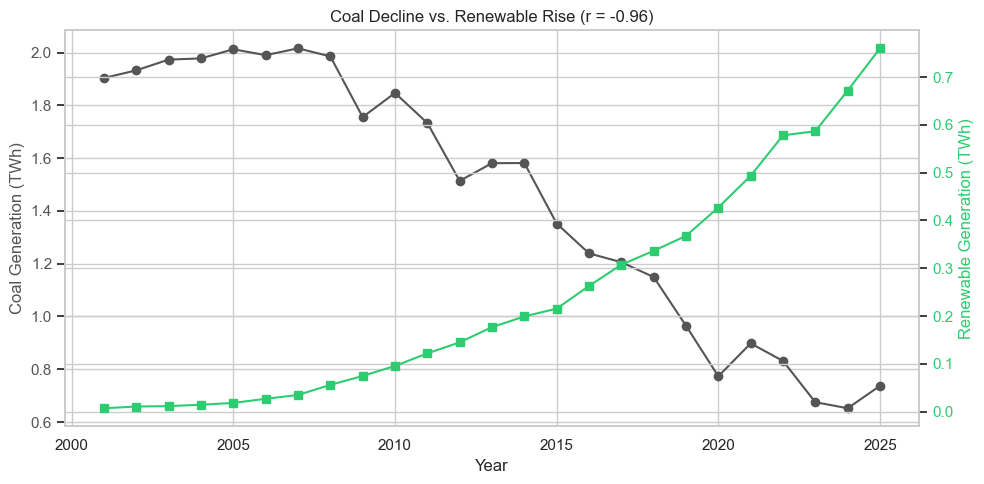

In [14]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Year')
ax1.set_ylabel('Coal Generation (TWh)', color='#555555')
ax1.plot(gen_df['Year'], gen_df['Coal_Generation_TWh'], color='#555555', marker='o', label='Coal')
ax1.tick_params(axis='y', labelcolor='#555555')

ax2 = ax1.twinx()
ax2.set_ylabel('Renewable Generation (TWh)', color='#2ecc71')
ax2.plot(gen_df['Year'], gen_df['Renewable_Gen_TWh'], color='#2ecc71', marker='s', label='Renewables (Wind + Solar)')
ax2.tick_params(axis='y', labelcolor='#2ecc71')

plt.title(f'Coal Decline vs. Renewable Rise (r = -0.96)')
fig.tight_layout()
plt.savefig('pearson_dual_axis.png', dpi=150)
plt.show()

#### Figure 5. Coal vs renewable generation correlation

Figure 5 shows an almost perfect inverse linear relationship, with an $r$-value of -0.96. The effectively zero p-value confirms this is not due to random chance. 

So, the premise of our project: The strong negative correlation indicates that years with lower coal generation tended to coincide with years of higher renewable generation. This is consistent with a broad transition in the U.S. electricity mix, but it should not be interpreted as proof that renewable growth alone caused the decline in coal.

### 6.2 Mann-Whitney U Test



We used the Mann–Whitney U test to compare annual wind and solar capacity factors because the sample size is small and we preferred a method that does not assume normally distributed values.

One limitation is that the yearly observations are ordered in time, so they are not perfectly independent in the strictest sense.

In [15]:
u_stat, p_val_u = stats.mannwhitneyu(cf_df['Wind_CF'], cf_df['Solar_CF'], alternative='two-sided')
print(f'U-statistic = {u_stat:.4f}\nP-Value = {p_val_u:.5f}')

U-statistic = 100.0000
P-Value = 0.00018


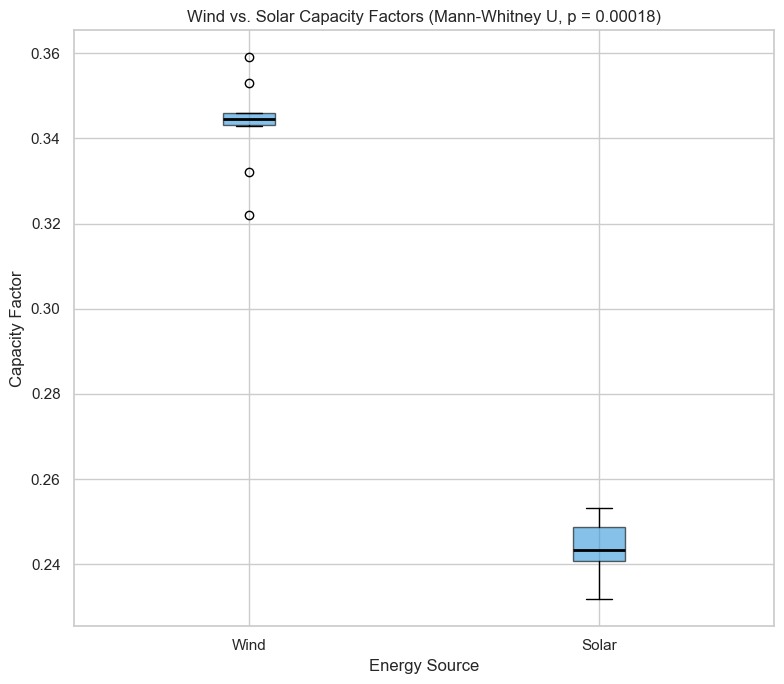

In [22]:
fig, ax = plt.subplots(figsize=(8, 7))

ax.boxplot(
    [cf_df['Wind_CF'], cf_df['Solar_CF']],
    tick_labels=['Wind', 'Solar'],
    patch_artist=True,
    boxprops=dict(facecolor='#3498db', alpha=0.6),
    medianprops=dict(color='black', linewidth=2)
)

ax.set_title('Wind vs. Solar Capacity Factors (Mann-Whitney U, p = 0.00018)')
ax.set_ylabel('Capacity Factor')
ax.set_xlabel('Energy Source')
plt.tight_layout()
plt.savefig('mannwhitney_boxplot.png', dpi=150)
plt.show()

#### Figure 6. Wind vs solar capacity factor comparison

Figure 6 shows that wind farms operated at a significantly higher capacity factor than solar installations, with a Mann-Whitney U-statistic of 100.0 and a p-value of 0.00018. This highlights the inherent physical limitations of intermittent renewable sources; wind tends to blow more consistently across a 24-hour cycle, whereas solar capacity is strictly bottlenecked by daylight hours and weather conditions, capping its maximum efficiency.

### 6.3 One-Way ANOVA



We used a one-way ANOVA to test whether the mean annual generation levels differed among natural gas, wind, and solar across the study period.

ANOVA assumes independent observations, approximate normality within groups, and reasonably comparable variances. Because these are annual time-series observations, the independence assumption is only approximate. Therefore, this test should be interpreted as a broad comparison of historical average generation levels rather than a full causal or operational assessment of grid reliability.

In [17]:
f_stat, p_val_f = stats.f_oneway(gen_df['Natural_Gas_Generation_TWh'],
                                 gen_df['Wind_Generation_TWh'],
                                 gen_df['Solar_Generation_TWh'])
print(f"F-statistic = {f_stat:.4f}, p-value = {p_val_f:.4e}")

F-statistic = 152.8549, p-value = 1.2198e-26


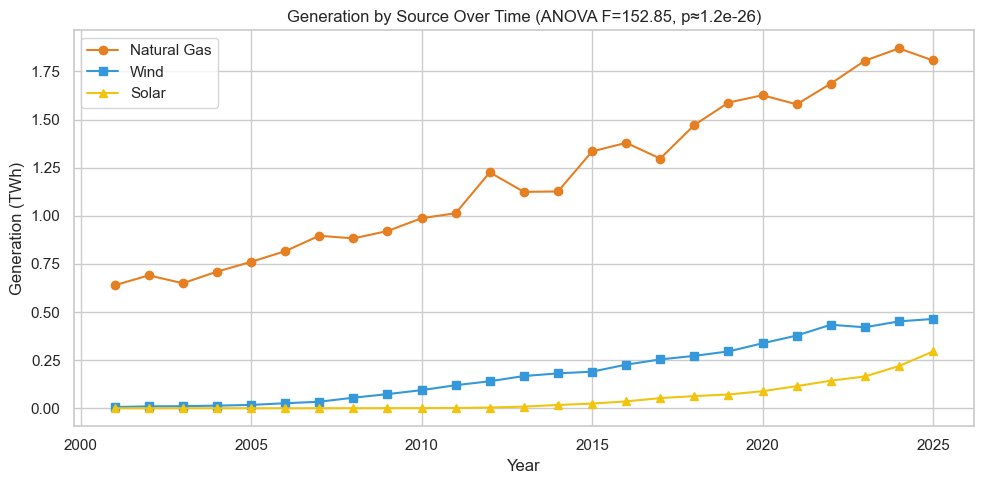

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(gen_df['Year'], gen_df['Natural_Gas_Generation_TWh'], label='Natural Gas', color='#e67e22', marker='o')
ax.plot(gen_df['Year'], gen_df['Wind_Generation_TWh'], label='Wind', color='#3498db', marker='s')
ax.plot(gen_df['Year'], gen_df['Solar_Generation_TWh'], label='Solar', color='#f1c40f', marker='^')

ax.set_title('Generation by Source Over Time (ANOVA F=152.85, p≈1.2e-26)')
ax.set_xlabel('Year')
ax.set_ylabel('Generation (TWh)')
ax.legend()
plt.tight_layout()
plt.savefig('anova_generation_lines.png', dpi=150)
plt.show()

#### Figure 7. Annual generation comparison

Figure 7 shows that the average annual generation levels of natural gas, wind, and solar were not equal over the study period. In this dataset, natural gas generated substantially more electricity than wind or solar on average. This finding supports the descriptive observation that, although renewables have grown quickly, natural gas remained a much larger contributor to total U.S. electricity generation during the years examined. However, this result should not be interpreted as a direct measure of technological superiority or as proof of what the grid can or cannot rely on operationally.

### 6.4 Simple Linear Regression



Finally, the project aims to understand how implementation costs impact adoption speed. A simple linear regression model tests whether the declining Levelized Cost of Energy (LCOE) for solar acts as a statistically significant predictor for the actual amount of solar energy integrated into the grid (Generation in TWh)

Because both variables change systematically over time, this model should be interpreted as an association between two trending variables rather than a causal estimate of the effect of cost on generation.

In [19]:
slope, intercept, r_value, p_value_reg, std_err = stats.linregress(
    merged_solar_df['US_LCOE_USD_per_kWh'],
    merged_solar_df['Solar_Generation_TWh']
)
print(f"Linear Regression (Solar LCOE predicting Generation):")
print(f"R-squared = {r_value**2:.4f}, p-value = {p_value_reg:.4f}")

Linear Regression (Solar LCOE predicting Generation):
R-squared = 0.6246, p-value = 0.0005


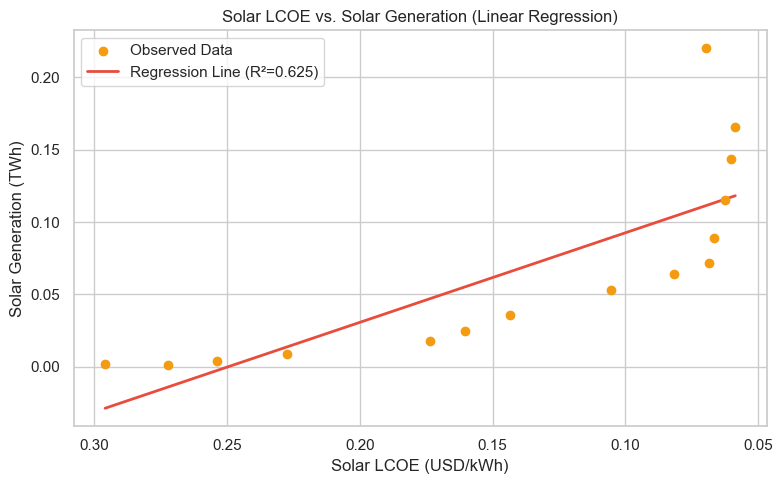

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(merged_solar_df['US_LCOE_USD_per_kWh'], merged_solar_df['Solar_Generation_TWh'],
           color='#f39c12', zorder=5, label='Observed Data')

x_line = np.linspace(merged_solar_df['US_LCOE_USD_per_kWh'].min(),
                     merged_solar_df['US_LCOE_USD_per_kWh'].max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='#e74c3c', linewidth=2, label=f'Regression Line (R²=0.625)')

ax.set_title('Solar LCOE vs. Solar Generation (Linear Regression)')
ax.set_xlabel('Solar LCOE (USD/kWh)')
ax.set_ylabel('Solar Generation (TWh)')
ax.legend()
ax.invert_xaxis()
plt.tight_layout()
plt.savefig('regression_solar.png', dpi=150)
plt.show()

#### Figure 8. Solar LCOE vs solar generation regression

Figure 8 shows a strong association between lower solar LCOE and higher solar generation in the overlapping sample. The $R^2$ value suggests that a substantial share of the variation in annual solar generation is aligned with variation in annual solar cost, but this should not be interpreted to mean that cost alone determines adoption. Policy incentives, infrastructure expansion, technological improvements, and broader electricity demand also likely contributed.

## 7. Results
The analyses produced four main findings. First, annual coal generation and annual renewable generation were strongly negatively correlated, consistent with a major change in the U.S. electricity mix over time. Second, wind capacity factors were significantly higher than solar capacity factors in the years observed. Third, renewable costs—especially solar LCOE—declined sharply over the study period. Fourth, lower solar LCOE was strongly associated with higher solar generation, suggesting that improved affordability accompanied increased deployment. Taken together, these results indicate that renewable energy became more economically competitive and more prominent in the U.S. electricity system, even though conventional sources remained important contributors to total generation.


### Interpretation of Results

Overall, the results suggest that the U.S. electricity sector is going through a clear transition away from coal and toward renewable energy, although that transition is not occurring evenly across all energy sources. The Pearson correlation analysis showed a very strong negative relationship between coal generation and renewable generation ($r=−0.9604$, $ $ $p<0.001$), indicating that as renewable generation increased over time, coal’s role declined substantially. Although this relationship does not by itself prove causation, it strongly supports the idea that renewables have become an increasingly important part of the national energy mix.

At the same time, the results show that lower cost and stronger operational performance are not the same thing. The regression analysis found that declining solar LCOE was strongly associated with increasing solar generation ($R^2=0.6246$, $ $ $p=0.0005$), suggesting that improved affordability has been an important driver of solar adoption. However, the Mann-Whitney U test showed a significant difference in capacity factor between wind and solar ($p=0.00018$), with wind performing better overall. This means that even though both sources are renewable, they do not contribute in exactly the same way: solar has become increasingly cost-competitive, but its output remains more limited by daylight and weather, while wind tends to provide more consistent generation.

This difference between cost and performance also helps explain the ANOVA results, which showed a statistically significant difference in generation levels among natural gas, wind, and solar ($F=152.8549$, $ $ $p<0.001$). Even as renewables continue to grow, natural gas still produces much more electricity than either wind or solar. This suggests that lower cost alone is not enough for a source to dominate total generation; dispatchability, reliability, and the ability to provide steady large-scale power still matter. In practical terms, the data indicate that coal is being displaced, renewables are expanding rapidly, and natural gas continues to serve as a major supporting source while the grid adapts to more intermittent renewable energy.

Taken together, these outcomes answer the research question by showing that conventional and renewable energy sources differ in both cost and efficiency-related performance. Renewable energy is increasingly viable economically, and its growth is clearly reshaping the U.S. energy landscape. However, conventional sources, especially natural gas, still retain an important advantage in stable, high-volume electricity generation. Therefore, the results suggest that the switch to renewable energy is real and accelerating, but a full replacement of conventional sources will likely depend on continued cost reductions, improvements in storage technology, and further modernization of grid infrastructure.

## 8. Limitations

Although the results give strong evidence of a major shift in the U.S. electricity sector, this project has several important limitations. First, the final merged dataset used for direct comparison covers only a limited time period because the different sources did not all provide data for the exact same years. In particular, the final analytical dataset for the combined generation, capacity factor, and cost analysis is restricted to 2015–2024. This reduces the sample size for some of the statistical tests and means that the conclusions should be interpreted as evidence of recent trends rather than a complete picture of the full long-term energy transition.

A second limitation is that the variables used in this project are useful proxies, but they do not capture every relevant dimension of energy performance. Capacity factor is a reasonable measure of working efficiency or consistency, but it is not the same as total technical efficiency. Similarly, LCOE is a widely used cost metric, but it does not fully account for other real-world costs such as transmission upgrades, storage requirements, policy incentives, maintenance differences, regional fuel prices, or grid integration complications. As a result, comparing sources only through capacity factor and LCOE simplifies a much more complicated energy system.

There are also important methodological issues. The Pearson correlation and linear regression analyses show strong statistical relationships, but they do not establish immediate causation. For example, the strong negative relationship between coal generation and renewable generation does not necessarily mean that renewable growth alone caused coal to decline; other factors such as environmental regulations, plant retirements, changes in fuel prices, and broader technical improvements may also have contributed. Likewise, the regression linking lower solar LCOE to higher solar generation suggests that falling costs are an important driver of adoption, but it does not capture other influences such as tax credits, state policy, transmission access, or changing electricity demand.

Even with these limitations, the findings still offer a meaningful picture of how the U.S. energy mix is evolving. The results consistently show that renewable energy is becoming more economically competitive, that wind tends to outperform solar in capacity factor, and that natural gas still plays a major role because it can provide stable, dispatchable power at large scale. This suggests that the switch to renewable energy is not simply a question of replacing one source with another, but rather a wider restructuring of the grid in which cost, reliability, and infrastructure all matter at the same time.

Additional research could improve this analysis by using regional or state-level panel data, adding additional variables such as storage capacity, emissions, policy incentives, and transmission investment, and applying more advanced time-series or multivariable regression methods. It would also be useful to compare a wider set of technologies, including hydroelectric, nuclear, and battery storage, in order to better understand how different sources interact in a modern power system. These extensions would provide a more complete explanation of not just whether renewable adoption is increasing, but also what conditions make that transition faster and more reliable.

## 9. Conclusion
This project compared conventional and renewable electricity sources in the United States using public data on generation, capacity factor, and renewable cost. The results show that renewable energy has become increasingly important in the U.S. electricity system, with wind and solar expanding as coal declined. At the same time, the findings show that growth in renewables does not eliminate meaningful differences across technologies: wind showed higher annual capacity factors than solar, and natural gas remained much larger in average annual generation than either renewable source in the observed period.
Overall, the evidence suggests that the U.S. energy transition is visible both economically and operationally. Renewable technologies, especially solar, have become much more cost-competitive, and that cost decline is strongly associated with increased deployment. However, the transition remains incomplete, and understanding it fully would require additional analysis of storage, regional variation, policy, and grid integration.


## 10. References

U.S. Energy Information Administration. (n.d.). Annual capacity factors. EIA. Retrieved March 14, 2026, from https://www.eia.gov/electricity/annual/html/epa_04_08_b.html

U.S. Energy Information Administration. (n.d.). Electric Power Monthly. EIA. Retrieved March 14, 2026, from https://www.eia.gov/electricity/monthly/

U.S. Energy Information Administration. (n.d.). Electricity Data Browser. EIA. Retrieved March 14, 2026, from https://www.eia.gov/electricity/data/browser/

International Renewable Energy Agency. (2025). Renewable power generation costs in 2024. IRENA. https://www.irena.org/Publications/2025/Jun/Renewable-Power-Generation-Costs-in-2024
